#hypothesis
# '451', '458', '480' -> EXCEPTION NO QUESTION FROM 
HYPOTHESIS
1.어휘가 덜 다양하고 말이 간결하다
2.부정적인 어휘빈도
3.높낮이는 ?
4.

In [1]:
import pandas as pd
EXCEPTION_NUMBER=['451','458','480']
meta=pd.read_csv(r"D:\depression_dataset(DAIC-WOZ)\metadataset.csv")
meta

c:\Users\Lenovo\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Participant_ID,Binary,Score,Gender,Transcript,Audio
0,300,0,2,1,D:\depression_dataset(DAIC-WOZ)\300_P\300_clea...,D:\depression_dataset(DAIC-WOZ)\300_P\300_AUDI...
1,301,0,3,1,D:\depression_dataset(DAIC-WOZ)\301_P\301_clea...,D:\depression_dataset(DAIC-WOZ)\301_P\301_AUDI...
2,302,0,4,1,D:\depression_dataset(DAIC-WOZ)\302_P\302_clea...,D:\depression_dataset(DAIC-WOZ)\302_P\302_AUDI...
3,303,0,0,0,D:\depression_dataset(DAIC-WOZ)\303_P\303_clea...,D:\depression_dataset(DAIC-WOZ)\303_P\303_AUDI...
4,304,0,6,0,D:\depression_dataset(DAIC-WOZ)\304_P\304_clea...,D:\depression_dataset(DAIC-WOZ)\304_P\304_AUDI...
...,...,...,...,...,...,...
181,488,0,0,0,D:\depression_dataset(DAIC-WOZ)\488_P\488_clea...,D:\depression_dataset(DAIC-WOZ)\488_P\488_AUDI...
182,489,0,3,1,D:\depression_dataset(DAIC-WOZ)\489_P\489_clea...,D:\depression_dataset(DAIC-WOZ)\489_P\489_AUDI...
183,490,0,2,1,D:\depression_dataset(DAIC-WOZ)\490_P\490_clea...,D:\depression_dataset(DAIC-WOZ)\490_P\490_AUDI...
184,491,0,8,0,D:\depression_dataset(DAIC-WOZ)\491_P\491_clea...,D:\depression_dataset(DAIC-WOZ)\491_P\491_AUDI...


In [2]:
import pandas as pd
import numpy as np
import librosa
import os
from scipy import stats
from tqdm import tqdm

# =============================================================================
# 1. 텍스트 분석기 (TTR 추출)
# =============================================================================
class TextFeatureAnalysis:
    def _read_transcript(self, path):
        for sep in ['\t', ',']:
            for enc in ['utf-8', 'cp949']:
                try:
                    df = pd.read_csv(path, sep=sep, encoding=enc)
                    if df.shape[1] > 2 and any('speaker' in c.lower() for c in df.columns):
                        return df
                except: continue
        return None

    def extract(self, row):
        transcript_path = row['Transcript']
        results = {}
        try:
            df = self._read_transcript(transcript_path)
            if df is None: return pd.Series()

            df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
            if 'question_label' not in df.columns: return pd.Series()

            # 전처리: 첫 Participant 이전 제거
            mask = df['speaker'].str.lower() != 'participant'
            if not mask.any(): return pd.Series()
            df = df.loc[mask.idxmax():].reset_index(drop=True)
            df['question_label'] = df['question_label'].fillna(method='ffill')

            # 참가자 발화만 그룹화
            participant_df = df[df['speaker'].str.lower() == 'participant']
            grouped = participant_df.dropna(subset=['question_label']).groupby('question_label')

            for label, group in grouped:
                # 텍스트 합치기 및 토큰화
                all_words = []
                for val in group['value'].astype(str):
                    words = [w for w in val.lower().split() if w not in {'hmm','um','uh'}]
                    all_words.extend(words)
                
                # TTR 계산
                if len(all_words) > 10: # 최소 10단어 이상일 때만 계산
                    ttr = len(set(all_words)) / len(all_words)
                    clean_label = str(label).strip()
                    results[f'TTR_{clean_label}'] = ttr
            
            return pd.Series(results)
        except: return pd.Series()

# =============================================================================
# 2. 통합 오디오 분석기 (Pitch, Jitter, Shimmer, HNR, Silence 한방에 추출)
# =============================================================================
class UnifiedAudioExtractor:
    def __init__(self, base_path):
        self.base_path = base_path

    def _read_transcript(self, path):
        # (위와 동일한 로직 생략 가능하지만 안전을 위해 포함)
        for sep in ['\t', ',']:
            for enc in ['utf-8', 'cp949']:
                try:
                    df = pd.read_csv(path, sep=sep, encoding=enc)
                    if df.shape[1] > 2: return df
                except: continue
        return None

    def calculate_jitter_shimmer(self, y, f0):
        # Jitter
        if len(f0) < 2: return np.nan, np.nan
        T = 1.0 / f0
        jitter = np.mean(np.abs(np.diff(T))) / np.mean(T)
        
        # Shimmer (RMS 에너지 기반)
        hop_length = int(len(y) / len(f0))
        rmse = librosa.feature.rms(y=y, frame_length=2048, hop_length=hop_length)[0]
        rmse = rmse[:len(f0)] # 길이 맞춤
        if np.mean(rmse) > 0:
            shimmer = np.mean(np.abs(np.diff(rmse))) / np.mean(rmse)
        else:
            shimmer = np.nan
        return jitter, shimmer

    def extract(self, row):
        pid = str(row['Participant_ID'])
        transcript_path = row['Transcript']
        audio_path = os.path.join(self.base_path, f"{pid}_P", f"{pid}_AUDIO.wav")
        
        if not os.path.exists(audio_path): return pd.Series()

        try:
            # 1. Transcript에서 발화 구간 정보 가져오기
            df = self._read_transcript(transcript_path)
            if df is None: return pd.Series()
            df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
            part_df = df[df['speaker'].str.lower() == 'participant'].copy()
            
            # 2. 행동 특징 (Speaking Rate) 계산
            part_df['duration'] = part_df['stop_time'] - part_df['start_time']
            total_duration = part_df['duration'].sum()
            all_text = " ".join(part_df['value'].astype(str).tolist())
            word_count = len(all_text.split())
            wps = word_count / total_duration if total_duration > 0 else np.nan

            # 3. 오디오 분석 (Top 4 긴 구간만 샘플링)
            top_segments = part_df[part_df['duration'] > 2.0].sort_values(by='duration', ascending=False).head(4)
            
            pitches, centroids, jitters, shimmers, hnrs, silences = [], [], [], [], [], []

            for _, r in top_segments.iterrows():
                try:
                    y, sr = librosa.load(audio_path, sr=16000, offset=r['start_time'], duration=r['duration'])
                    
                    # (A) Pitch & Jitter & Shimmer
                    f0 = librosa.yin(y, fmin=60, fmax=400) # yin이 빠름
                    f0 = f0[~np.isnan(f0)]
                    if len(f0) > 0:
                        pitches.append(np.std(f0)) # Pitch Std
                        jit, shim = self.calculate_jitter_shimmer(y, f0)
                        jitters.append(jit)
                        shimmers.append(shim)

                    # (B) Spectral Centroid
                    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
                    centroids.append(np.mean(cent))

                    # (C) HNR (Harmonic-to-Noise Ratio)
                    y_harmonic, y_percussive = librosa.effects.hpss(y)
                    h_energy = np.mean(y_harmonic**2)
                    n_energy = np.mean(y_percussive**2)
                    if n_energy > 0: hnrs.append(10 * np.log10(h_energy/n_energy))

                    # (D) Silence Ratio
                    non_silent = librosa.effects.split(y, top_db=20)
                    non_silent_dur = sum([end-start for start, end in non_silent]) / sr
                    total_dur = len(y)/sr
                    if total_dur > 0: silences.append((total_dur - non_silent_dur)/total_dur)

                except: continue

            # 결과 집계 (평균)
            results = {
                'Speaking_Rate_WPS': wps,
                'Pitch_Std': np.mean(pitches) if pitches else np.nan,
                'Spectral_Centroid': np.mean(centroids) if centroids else np.nan,
                'Jitter': np.mean(jitters) if jitters else np.nan,
                'Shimmer': np.mean(shimmers) if shimmers else np.nan,
                'HNR_dB': np.mean(hnrs) if hnrs else np.nan,
                'Silence_Ratio': np.mean(silences) if silences else np.nan
            }
            return pd.Series(results)

        except: return pd.Series()

In [3]:
# ---------------------------------------------------------
# 설정 (경로 확인 필수!)
# ---------------------------------------------------------
# meta 데이터프레임이 이미 로드되어 있다고 가정합니다.
# 없다면: meta = pd.read_excel("metadata_path.xlsx")
base_path = r"D:\depression_dataset(DAIC-WOZ)" 

print(f"🚀 분석 시작! 대상: {len(meta)}명")

# 1. 텍스트 분석 (TTR)
print("Processing Text Features...")
text_analyzer = TextFeatureAnalysis()
tqdm.pandas()
df_text = meta.progress_apply(text_analyzer.extract, axis=1)

# 2. 오디오 통합 분석 (Pitch, Jitter, HNR 등등 다 포함)
print("Processing Audio Features (Optimized)...")
audio_extractor = UnifiedAudioExtractor(base_path)
df_audio = meta.progress_apply(audio_extractor.extract, axis=1)

# 3. 데이터 합치기
print("Merging data...")
df_final = pd.concat([meta, df_text, df_audio], axis=1)

# 중복 컬럼 제거 및 확인
df_final = df_final.loc[:, ~df_final.columns.duplicated()]
print(f"✅ 최종 데이터셋 완성! 크기: {df_final.shape}")
print("Columns:", df_final.columns.tolist())

# 저장 (안전을 위해)
#df_final.to_csv("DAIC_WOZ_ML_Ready.csv", index=False, encoding='utf-8-sig')

🚀 분석 시작! 대상: 186명
Processing Text Features...


  0%|          | 0/186 [00:00<?, ?it/s]C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26648\2818389236.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['question_label'] = df['question_label'].fillna(method='ffill')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26648\2818389236.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['question_label'] = df['question_label'].fillna(method='ffill')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26648\2818389236.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['question_label'] = df['question_label'].fillna(method='ffill')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26648\2818389236.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a fu

Processing Audio Features (Optimized)...


100%|██████████| 186/186 [03:56<00:00,  1.27s/it]

Merging data...
✅ 최종 데이터셋 완성! 크기: (186, 21)
Columns: ['Participant_ID', 'Binary', 'Score', 'Gender', 'Transcript', 'Audio', 'TTR_Daily Habits / Lifestyle', 'TTR_Depression Symptoms Direct', 'TTR_Emotion / Mood', 'TTR_Open-ended Encouragement', 'TTR_Preference', 'TTR_Self-perception / Personality', 'TTR_Small talk', 'TTR_Social / Family / Relationship', 'Speaking_Rate_WPS', 'Pitch_Std', 'Spectral_Centroid', 'Jitter', 'Shimmer', 'HNR_dB', 'Silence_Ratio']


🎯 사용될 피처 수: 15개

📊 [Random Forest] 5-Fold 검증 결과
Accuracy : 0.6994
F1-Score : 0.2517 (★핵심 지표)
ROC-AUC  : 0.6657


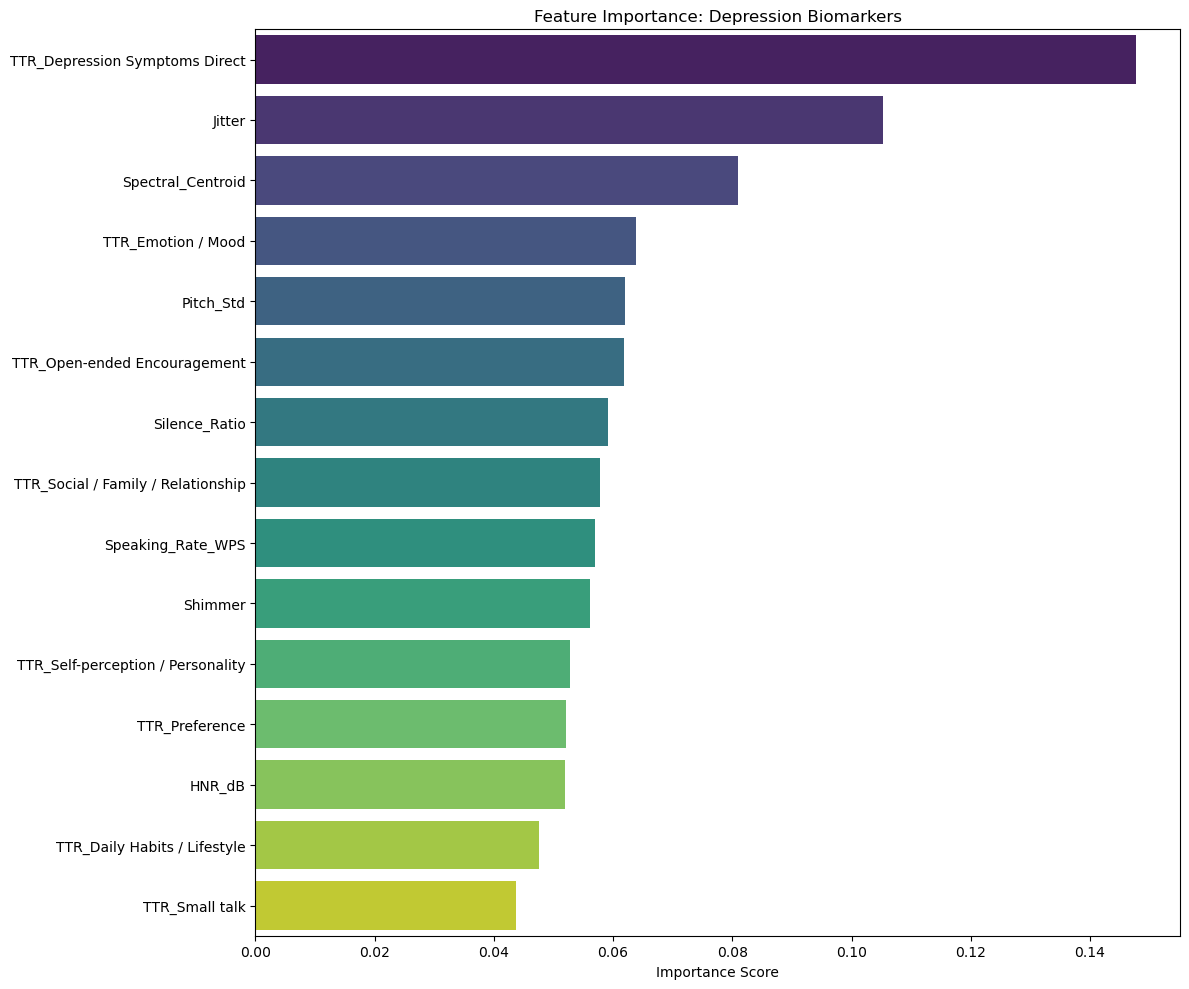


🏆 Top 5 Features:
1. TTR_Depression Symptoms Direct (0.1477)
2. Jitter (0.1053)
3. Spectral_Centroid (0.0810)
4. TTR_Emotion / Mood (0.0639)
5. Pitch_Std (0.0620)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Feature Selection (자동 감지)
# ---------------------------------------------------------
# 우리가 만든 피처들만 쏙 뽑아냅니다.
target_keywords = [
    'TTR_', 'Pitch_Std', 'Spectral_Centroid', 'Jitter', 
    'Shimmer', 'HNR_dB', 'Silence_Ratio', 'Speaking_Rate'
]
feature_cols = [c for c in df_final.columns if any(k in c for k in target_keywords)]

print(f"🎯 사용될 피처 수: {len(feature_cols)}개")

X = df_final[feature_cols].copy()
y = df_final['Binary'].copy()

# ---------------------------------------------------------
# 2. 전처리 & 모델링
# ---------------------------------------------------------
# NaN 처리 (평균값 대치)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 랜덤 포레스트 (Balanced Weight 적용)
rf = RandomForestClassifier(
    n_estimators=300, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# ---------------------------------------------------------
# 3. 교차 검증 (Cross Validation)
# ---------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(rf, X_imputed, y, cv=cv, scoring=['accuracy', 'f1', 'roc_auc'])

print("\n" + "="*40)
print("📊 [Random Forest] 5-Fold 검증 결과")
print("="*40)
print(f"Accuracy : {scores['test_accuracy'].mean():.4f}")
print(f"F1-Score : {scores['test_f1'].mean():.4f} (★핵심 지표)")
print(f"ROC-AUC  : {scores['test_roc_auc'].mean():.4f}")

# ---------------------------------------------------------
# 4. 중요도 시각화
# ---------------------------------------------------------
rf.fit(X_imputed, y) # 전체 데이터로 재학습
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 10))
sns.barplot(x=importances[indices], y=X_imputed.columns[indices], palette="viridis")
plt.title("Feature Importance: Depression Biomarkers")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Top 5 출력
print("\n🏆 Top 5 Features:")
for i in range(5):
    if i < len(indices):
        print(f"{i+1}. {X_imputed.columns[indices[i]]} ({importances[indices[i]]:.4f})")

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer # 이미 X_imputed에 적용되어 있다고 가정

# X_imputed와 y는 이전 단계에서 전처리된 데이터프레임입니다.
X = X_imputed.copy()
y = y.copy()

def get_optimal_threshold(y_true, y_proba):
    """최적의 F1 스코어를 주는 임계값(Threshold)을 계산합니다."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    f1_scores = np.nan_to_num(f1_scores)
    
    best_idx = np.argmax(f1_scores)
    # 임계값 리스트는 precision/recall보다 길이가 1 짧으므로, 마지막 인덱스를 처리
    if best_idx == len(thresholds):
        return thresholds[-1] 
    else:
        return thresholds[best_idx]

def cross_validate_and_tune(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # 결과를 담을 리스트
    f1_scores_tuned = []
    auc_scores = []
    
    print("🚀 현실적인 임계값 탐색 및 검증 시작 (5-Fold)...")
    
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        # 1. 훈련
        model.fit(X_train, y_train)
        
        # 2. 훈련 데이터로 확률 예측 (Tuning을 위한 확률)
        y_train_proba = model.predict_proba(X_train)[:, 1]
        
        # 3. 훈련 데이터를 사용해 최적 임계값 찾기 (Leakage 방지)
        opt_threshold = get_optimal_threshold(y_train, y_train_proba)
        
        # 4. 검증 데이터로 확률 예측
        y_val_proba = model.predict_proba(X_val)[:, 1]
        
        # 5. 최적 임계값 적용 및 F1 계산
        y_val_pred = (y_val_proba >= opt_threshold).astype(int)
        
        f1_scores_tuned.append(f1_score(y_val, y_val_pred))
        auc_scores.append(roc_auc_score(y_val, y_val_proba))
        
        print(f"  [Fold {fold+1}] Best Threshold: {opt_threshold:.4f}, F1-Score: {f1_scores_tuned[-1]:.4f}")

    print("\n" + "="*40)
    print("✅ 최종 현실적 검증 결과 (Tuned F1)")
    print("="*40)
    print(f"평균 F1-Score : {np.mean(f1_scores_tuned):.4f}")
    print(f"평균 ROC-AUC  : {np.mean(auc_scores):.4f}")
    
# 모델 정의 (이전과 동일)
rf_model_tuned = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)

cross_validate_and_tune(rf_model_tuned, X, y)

c:\Users\Lenovo\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


NameError: name 'X_imputed' is not defined